In [130]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path

import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [131]:
base_url = "http://personal-laptop.local:8080/"


In [132]:
script_dir = Path().resolve().parent

def create_url(base_url,first_part_endpoint,second_part_endpoint):
    return base_url + first_part_endpoint + second_part_endpoint
def getData(url):
    response = requests.get(url)

    # Check response status
    if response.status_code == 200:
        data = response.json()
        print(f"Received {len(data)} records.")
        return data
    else:
        print(f"Error: {response.status_code}")

def saveDataIntoDataFolder(url,data_file_name):
    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (data_file_name + ".json")
    
    data = getData(url)
    
    if data:
        with open(file_path, 'w') as file:
            json.dump(data, file)
        print(f"Data saved to {file_path}")
    else:
        print("No data to save.")


def loadDataFromFile(file_name):
    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None


In [133]:
first_part_endpoint = "dataAnalysisEndpoints/"
second_part_endpoint = "getAllUserInputsExperimentState"        

url = create_url(base_url,first_part_endpoint,second_part_endpoint)


saveDataIntoDataFolder(url,"UserInputs")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Received 381 records.
Data saved to /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/UserInputs.json


In [134]:
saveDataIntoDataFolder(url,"UserInputs")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Received 381 records.
Data saved to /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/UserInputs.json


In [135]:
df_userInputData = loadDataFromFile("UserInputs")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 381 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/UserInputs.json


In [136]:
df_userInputData

,_id,experimentState,timestamp,userInputCategory,details
0,{'$oid': '6849ace703a598ff63a65bf8'},StartingExperiment,{'$date': 1749658855857},ExperimentState,NaN
1,{'$oid': '6849aefb03a598ff63a6667f'},InsertingSourcePollutant,{'$date': 1749659387774},ExperimentState,"{'are-doors-opened': 'on', 'are-people-inside'..."
2,{'$oid': '6849b77503a598ff63a68c90'},RemovingSourcePollutant,{'$date': 1749661557509},ExperimentState,NaN
3,{'$oid': '6849ba8d03a598ff63a69cd3'},InsertingSourcePollutant,{'$date': 1749662349567},ExperimentState,"{'are-doors-opened': 'on', 'are-people-inside'..."
4,{'$oid': '6849c2dc03a598ff63a6c299'},RemovingSourcePollutant,{'$date': 1749664476491},ExperimentState,NaN
...,...,...,...,...,...
376,{'$oid': '6880cd038e240ca201279789'},StartingExperiment,{'$date': 1753271555828},ExperimentState,NaN
377,{'$oid': '6880cf7e8e240ca201279c6c'},InsertingSourcePollutant,{'$date': 1753272190259},ExperimentState,"{'are-doors-opened': 'on', 'back-wall': '', 'f..."
378,{'$oid': '6880d18d8e240ca20127a0ca'},RemovingSourcePollutant,{'$date': 1753272717850},ExperimentState,NaN
379,{'$oid': '6880d40d8e240ca20127a5b6'},StartingExperiment,{'$date': 1753273357724},ExperimentState,NaN


In [137]:
if 'details' in df_userInputData.columns:
    details_df = df_userInputData["details"].apply(pd.Series)
    
    # Then join with the original DataFrame (drop the nested 'details' if desired)
    df_userInputData = pd.concat([df_userInputData.drop(columns=["details"]), details_df], axis=1)

In [138]:
df_userInputData.columns

Index([               '_id',    'experimentState',          'timestamp',
        'userInputCategory',                    0,   'are-doors-opened',
        'are-people-inside', 'are-windows-opened',         'front-wall',
                'item-used',              'notes',     'pollutant-type',
            'quantity-used',               'room',    'side-right-wall',
                'back-wall',     'side-left-wall',        'are-fans-on'],
      dtype='object')

In [139]:
if 0 in df_userInputData.columns:
    df_userInputData =df_userInputData.drop(columns=[0])

In [140]:
# Convert epoch (assumes seconds) to datetime in local time
df_userInputData["epoch_ms"] = df_userInputData["timestamp"].apply(lambda x: x["$date"])
df_userInputData["timestamp_local"] = pd.to_datetime(df_userInputData["epoch_ms"], unit="ms").dt.tz_localize("UTC").dt.tz_convert("Europe/Athens")
df_userInputData.drop(columns = ["timestamp"])

,_id,experimentState,userInputCategory,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall,back-wall,side-left-wall,are-fans-on,epoch_ms,timestamp_local
0,{'$oid': '6849ace703a598ff63a65bf8'},StartingExperiment,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749658855857,2025-06-11 19:20:55.857000+03:00
1,{'$oid': '6849aefb03a598ff63a6667f'},InsertingSourcePollutant,ExperimentState,on,on,on,1.5,φαρμακευτική λοτιόν,,VOC,δύο κουταλιές της σούπας,Σαλόνι,1.7,NaN,NaN,NaN,1749659387774,2025-06-11 19:29:47.774000+03:00
2,{'$oid': '6849b77503a598ff63a68c90'},RemovingSourcePollutant,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749661557509,2025-06-11 20:05:57.509000+03:00
3,{'$oid': '6849ba8d03a598ff63a69cd3'},InsertingSourcePollutant,ExperimentState,on,on,on,1.5,Φαρμακευτικό αλκοόλ,,VOC,τρεις κουταλιά της σούπας,Σαλόνι,1.7,NaN,NaN,NaN,1749662349567,2025-06-11 20:19:09.567000+03:00
4,{'$oid': '6849c2dc03a598ff63a6c299'},RemovingSourcePollutant,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1749664476491,2025-06-11 20:54:36.491000+03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,{'$oid': '6880cd038e240ca201279789'},StartingExperiment,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1753271555828,2025-07-23 14:52:35.828000+03:00
377,{'$oid': '6880cf7e8e240ca201279c6c'},InsertingSourcePollutant,ExperimentState,on,NaN,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,,,1.1,NaN,1753272190259,2025-07-23 15:03:10.259000+03:00
378,{'$oid': '6880d18d8e240ca20127a0ca'},RemovingSourcePollutant,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1753272717850,2025-07-23 15:11:57.850000+03:00
379,{'$oid': '6880d40d8e240ca20127a5b6'},StartingExperiment,ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1753273357724,2025-07-23 15:22:37.724000+03:00


In [141]:
dimensions = ['front-wall','side-right-wall','back-wall','side-left-wall']
for dimension in dimensions:
    df_userInputData[dimension] = pd.to_numeric(df_userInputData[dimension], errors='coerce')

In [142]:
def filterUserInputData(dataframe,field,comparison,condition="NaN",oldData = False):
# Define the condition
    if comparison == "equals":
        condition = ((dataframe[field] == condition) & (dataframe["experimentState"] == "InsertingSourcePollutant"))
    if comparison == "not-equals":
        condition = (~(dataframe[field] == condition)& (dataframe["experimentState"] == "InsertingSourcePollutant"))     
    if comparison =="NaN":    
        condition = ((dataframe[field].isna()) & (dataframe["experimentState"] == "InsertingSourcePollutant"))
    # Get the indices of the rows that match the condition
    matching_indices = dataframe[condition].index
    # Initialize a list to collect the desired indices
    all_indices = []
    
    # Add previous, current, and next indices (if within bounds)
    for idx in matching_indices:
        if idx - 1 >= 0 and idx + 1 < len(dataframe) :
            if oldData == False:
                if (dataframe.iloc[idx-1]["experimentState"]=="StartingExperiment") and  (dataframe.iloc[idx+1]["experimentState"]=="RemovingSourcePollutant"):

                    all_indices.append(idx - 1)
                    all_indices.append(idx)
                    all_indices.append(idx + 1)
                #when we didn't use the start experiment state for all the experiments,only the inserting source and remove source
            elif oldData == True:
                if dataframe.iloc[idx+1]["experimentState"]=="RemovingSourcePollutant":
                    all_indices.append(idx)
                    all_indices.append(idx + 1) 
                
    
    # Remove duplicates and preserve order
    # Use dict.fromkeys to maintain order while removing duplicates
    all_indices = list(dict.fromkeys(all_indices))
    
    # Filter the DataFrame
    df_userInputData_filtered= dataframe.loc[all_indices]
    df_userInputData_filtered=df_userInputData_filtered.reset_index(drop = True)
    return df_userInputData_filtered

In [120]:
def takeTheUserInputDataFromParticularRoom(df_userInputData,particularRoom,oldData = False):
    df_userInputData_smallScale = filterUserInputData(df_userInputData,"room","equals",particularRoom,oldData)
    df_userInputData_smallScale = filterUserInputData(df_userInputData_smallScale,"item-used","equals","Φαρμακευτικό αλκοόλ 95%",oldData)
    df_userInputData_smallScale = filterUserInputData(df_userInputData_smallScale,"are-fans-on","NaN",oldData)
    df_userInputData_smallScale = filterUserInputData(df_userInputData_smallScale,"are-windows-opened","NaN",oldData)
    df_userInputData_smallScale = filterUserInputData(df_userInputData_smallScale,"notes","not-equals","ανεμιστήρας",oldData)
    df_userInputData_smallScale = df_userInputData_smallScale.reset_index(drop=True) 
    return df_userInputData_smallScale
def countPositionOfPollutantSource(df_userInputData_smallScale):
    df_unique_position_count = df_userInputData_smallScale.groupby(['front-wall', 'side-right-wall','back-wall','side-left-wall'], dropna=False).size().reset_index(name='count')
    return df_unique_position_count

In [121]:
def getTimeSeries(df_userInputData_smallScale):
    first_row= df_userInputData_smallScale.iloc[0]
    last_row = df_userInputData_smallScale.iloc[-1]
    start_time = first_row["epoch_ms"]
    end_time   = last_row["epoch_ms"] 
    first_part_endpoint = "timeSeriesEndpoints/"
    second_part_endpoint = "getTimeSeriesData?start=" + str(start_time) + '&end=' +str(end_time)
    file_name="TimeSeries"
    url = create_url(base_url,first_part_endpoint,second_part_endpoint)
    saveDataIntoDataFolder(url,file_name)
    df_timeSeries = loadDataFromFile(file_name)
    return df_timeSeries
def tranformTimeSeries(df_timeSeries):
    # 1. Select only the needed column
    df_timeSeriesExperiments = df_timeSeries[['timestamp', 'Id', 'BME680:breathVocEquivalent']].copy()
    # 2. Convert `timestamp` (UTC) to Europe/Athens tz-aware datetime
    df_timeSeriesExperiments['timestamp'] = (
        pd.to_datetime(df_timeSeriesExperiments['timestamp'], utc=True)
          .dt.tz_convert('Europe/Athens')
    )
    # 3. Create the two “Id=…:” columns
    
    df_timeSeriesExperiments['Id=1:BME680:breathVocEquivalent'] = np.where(
        df_timeSeriesExperiments['Id'] == 1, df_timeSeriesExperiments['BME680:breathVocEquivalent'], np.nan
    )
    df_timeSeriesExperiments['Id=2:BME680:breathVocEquivalent'] = np.where(
        df_timeSeriesExperiments['Id'] == 2, df_timeSeriesExperiments['BME680:breathVocEquivalent'], np.nan
    )
    
    # 4. Set timestamp as the row index
    #df_timeSeriesExperiments.set_index('timestamp', inplace=True)
    
    # 5. Drop the old Id+raw measurement columns
    df_timeSeriesExperiments = df_timeSeriesExperiments.drop(
        columns=['Id', 'BME680:breathVocEquivalent']
    )
    return df_timeSeriesExperiments

In [122]:
def sortUserIputDataToListBasedOfPosition(df_userInputData_smallScale,df_unique_position_count):
    list_of_userInputData_smallScale_based_of_position = []
    
    list_of_userInputData_smallScale_based_on_position = []

    for idx, row in df_unique_position_count.iterrows():
        mask = (
            (df_userInputData_smallScale['experimentState'] == "InsertingSourcePollutant") &
            (
                (df_userInputData_smallScale['front-wall'] == row['front-wall']) |
                (np.isnan(df_userInputData_smallScale['front-wall']) & np.isnan(row['front-wall']))
            ) &
            (
                (df_userInputData_smallScale['side-left-wall'] == row['side-left-wall']) |
                (np.isnan(df_userInputData_smallScale['side-left-wall']) & np.isnan(row['side-left-wall']))
            ) &
            (
                (df_userInputData_smallScale['back-wall'] == row['back-wall']) |
                (np.isnan(df_userInputData_smallScale['back-wall']) & np.isnan(row['back-wall']))
            ) &
            (
                (df_userInputData_smallScale['side-right-wall'] == row['side-right-wall']) |
                (np.isnan(df_userInputData_smallScale['side-right-wall']) & np.isnan(row['side-right-wall']))
            )
        )

        df_userInputData_individual_position = df_userInputData_smallScale[mask]
        list_of_userInputData_smallScale_based_on_position.append(df_userInputData_individual_position)

    return list_of_userInputData_smallScale_based_on_position


In [144]:
def print_time_series_based_of_position(index,df_userInputData_smallScale,df_timeSeriesExperiments,
                                        list_of_userInputData_smallScale_based_of_position,oldData = False):
    df_userInputData_smallScale_based_of_position = list_of_userInputData_smallScale_based_of_position[index]
    num_experiments = df_userInputData_smallScale_based_of_position.shape[0]
    fig, axes = plt.subplots(num_experiments, figsize=(14, 3 * num_experiments), sharex=False)
    if num_experiments == 1:
        axes = [axes]  # Wrap single Axes into a list
    title = f"BME680:breathVocEquivalent at the pollution source position to be "
    if (pd.isna(df_userInputData_smallScale_based_of_position.iloc[0]['front-wall'])==False):
       title =title + f"{df_userInputData_smallScale_based_of_position.iloc[0]['front-wall']} meters from the front wall, "
    if (pd.isna(df_userInputData_smallScale_based_of_position.iloc[0]['back-wall'])==False):
       title =title +f"{df_userInputData_smallScale_based_of_position.iloc[0]['back-wall']} meters from the back wall, "
    if (pd.isna(df_userInputData_smallScale_based_of_position.iloc[0]['side-right-wall'])==False):
       title =title+ f"{df_userInputData_smallScale_based_of_position.iloc[0]['side-right-wall']} meters from the side right wall, "
    if (pd.isna(df_userInputData_smallScale_based_of_position.iloc[0]['side-left-wall'])==False):
       title =title+ f"{df_userInputData_smallScale_based_of_position.iloc[0]['side-left-wall']} meters from the side left wall, "

        
    fig.suptitle(title)

    for i, (idx, row) in enumerate(df_userInputData_smallScale_based_of_position.iterrows()):
        # Filter the time series between start and end 
        removing_source_timestamp_condition = df_timeSeriesExperiments["timestamp"] <= df_userInputData_smallScale.iloc[idx + 1]["timestamp_local"]

        if (oldData == False):
              inserting_source_timestamp_condition  = df_timeSeriesExperiments["timestamp"] >= df_userInputData_smallScale.iloc[idx - 1]["timestamp_local"]             
        #create a pseudo start experiment 3 minutes before the source insertion    
        elif  (oldData == True):  
            inserting_source_timestamp_condition = df_userInputData_smallScale.iloc[idx]["timestamp_local"] - datetime.timedelta(minutes=3)
        data = df_timeSeriesExperiments[removing_source_timestamp_condition & post_created_start_experiment]         
        # Plot VOC data
        sns.lineplot(
            data=data, 
            x="timestamp",
            y='Id=1:BME680:breathVocEquivalent',
            label="Id=1",
            marker='o',
            ax=axes[i]
        )
        sns.lineplot(
            data=data,
            x="timestamp",
            y='Id=2:BME680:breathVocEquivalent',
            label="Id=2",
            marker='s',
            ax=axes[i]
        )
        print()
        subtitle="Στοιχεία για το μενωμένο πείραμα:"
        subtitle= subtitle+"Αντικείμενο που χρησιμοποιείται¨"+row["item-used"]+", "
        if (pd.isna(row["are-doors-opened"]) == False):
            subtitle = subtitle + "Οι πόρτες είναι ανοιχτές, "
        if (pd.isna(row["are-fans-on"]) == False):
            subtitle = subtitle + "Οι ανεμιστήρες είναι ενεργοποιημένοι, "
        if (pd.isna(row["are-people-inside"]) == False):
            subtitle = subtitle + "Βρίσκονται άνθρωποι μέσα, "
        if (pd.isna(row["are-windows-opened"]) == False):
            subtitle = subtitle + "Τα παράθυρα είναι ανοιχτά, "
        if (pd.isna(row["notes"])== False):
            subtitle= subtitle + "Σημειώσεις:"+ row["notes"]
        axes[i].set_title(subtitle);

        # Draw vertical line at inserting source timestamp
        inserting_source = df_userInputData_smallScale.iloc[idx]["timestamp_local"]
        if inserting_source:
            axes[i].axvline(
                inserting_source, 
                color='red', 
                linestyle='--', 
                linewidth=2,
                label='inserting_source'
            )
        
        axes[i].set_xlabel("Timestamp")
        axes[i].set_ylabel("VOC")
        axes[i].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    print("\n")

In [145]:
df_unique_position_count.columns


Index(['front-wall', 'side-right-wall', 'back-wall', 'side-left-wall',
       'count'],
      dtype='object')

In [146]:
df_userInputData_smallScale =takeTheUserInputDataFromParticularRoom(df_userInputData,"Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1")
df_userInputData_smallScale

,_id,experimentState,timestamp,userInputCategory,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall,back-wall,side-left-wall,are-fans-on,epoch_ms,timestamp_local
0,{'$oid': '687bb2e32f9e1ee587c33549'},StartingExperiment,{'$date': 1752937187709},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1752937187709,2025-07-19 17:59:47.709000+03:00
1,{'$oid': '687bb3e92f9e1ee587c337ad'},InsertingSourcePollutant,{'$date': 1752937449439},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752937449439,2025-07-19 18:04:09.439000+03:00
2,{'$oid': '687bb4da2f9e1ee587c339fe'},RemovingSourcePollutant,{'$date': 1752937690518},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1752937690518,2025-07-19 18:08:10.518000+03:00
3,{'$oid': '687bb6452f9e1ee587c33d06'},StartingExperiment,{'$date': 1752938053589},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1752938053589,2025-07-19 18:14:13.589000+03:00
4,{'$oid': '687bb6f62f9e1ee587c33e98'},InsertingSourcePollutant,{'$date': 1752938230079},ExperimentState,on,on,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1752938230079,2025-07-19 18:17:10.079000+03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,{'$oid': '687feb1354321b35d2e6382a'},InsertingSourcePollutant,{'$date': 1753213715180},ExperimentState,on,NaN,NaN,NaN,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,0.6,2.0,NaN,NaN,1753213715180,2025-07-22 22:48:35.180000+03:00
71,{'$oid': '687febf354321b35d2e63a15'},RemovingSourcePollutant,{'$date': 1753213939545},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1753213939545,2025-07-22 22:52:19.545000+03:00
72,{'$oid': '6880cd038e240ca201279789'},StartingExperiment,{'$date': 1753271555828},ExperimentState,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1753271555828,2025-07-23 14:52:35.828000+03:00
73,{'$oid': '6880cf7e8e240ca201279c6c'},InsertingSourcePollutant,{'$date': 1753272190259},ExperimentState,on,NaN,NaN,1.8,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,NaN,1753272190259,2025-07-23 15:03:10.259000+03:00


In [147]:
df_unique_position_count = countPositionOfPollutantSource(df_userInputData_smallScale)
df_unique_position_count

,front-wall,side-right-wall,back-wall,side-left-wall,count
0,1.8,NaN,NaN,1.1,12
1,NaN,0.6,2.0,NaN,5
2,NaN,NaN,1.2,1.2,4
3,NaN,NaN,1.7,0.3,4
4,NaN,NaN,NaN,NaN,50


In [148]:
df_timeSeries = getTimeSeries(df_userInputData_smallScale)
df_timeSeriesExperiments = tranformTimeSeries(df_timeSeries)

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Received 64010 records.
Data saved to /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/TimeSeries.json
/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 64010 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/TimeSeries.json


In [149]:
list_of_userInputData_smallScale_based_of_position = sortUserIputDataToListBasedOfPosition(df_userInputData_smallScale,df_unique_position_count)
print(list_of_userInputData_smallScale_based_of_position)

[                                     _id           experimentState  \
1   {'$oid': '687bb3e92f9e1ee587c337ad'}  InsertingSourcePollutant   
4   {'$oid': '687bb6f62f9e1ee587c33e98'}  InsertingSourcePollutant   
7   {'$oid': '687bba292f9e1ee587c34606'}  InsertingSourcePollutant   
10  {'$oid': '687bc4062f9e1ee587c35acd'}  InsertingSourcePollutant   
13  {'$oid': '687bcbf52f9e1ee587c36c6b'}  InsertingSourcePollutant   
16  {'$oid': '687bd5102f9e1ee587c3800b'}  InsertingSourcePollutant   
19  {'$oid': '687cf31b9ca8d3ed9388a101'}  InsertingSourcePollutant   
22  {'$oid': '687d08169ca8d3ed9388c9c1'}  InsertingSourcePollutant   
25  {'$oid': '687d1a9f29a17fa9a903c98f'}  InsertingSourcePollutant   
28  {'$oid': '687d31b3ef9fa667a2542024'}  InsertingSourcePollutant   
31  {'$oid': '687d4067ef9fa667a2544036'}  InsertingSourcePollutant   
73  {'$oid': '6880cf7e8e240ca201279c6c'}  InsertingSourcePollutant   

                   timestamp userInputCategory are-doors-opened  \
1   {'$date': 1752937

NameError: name 'post_created_start_experiment' is not defined

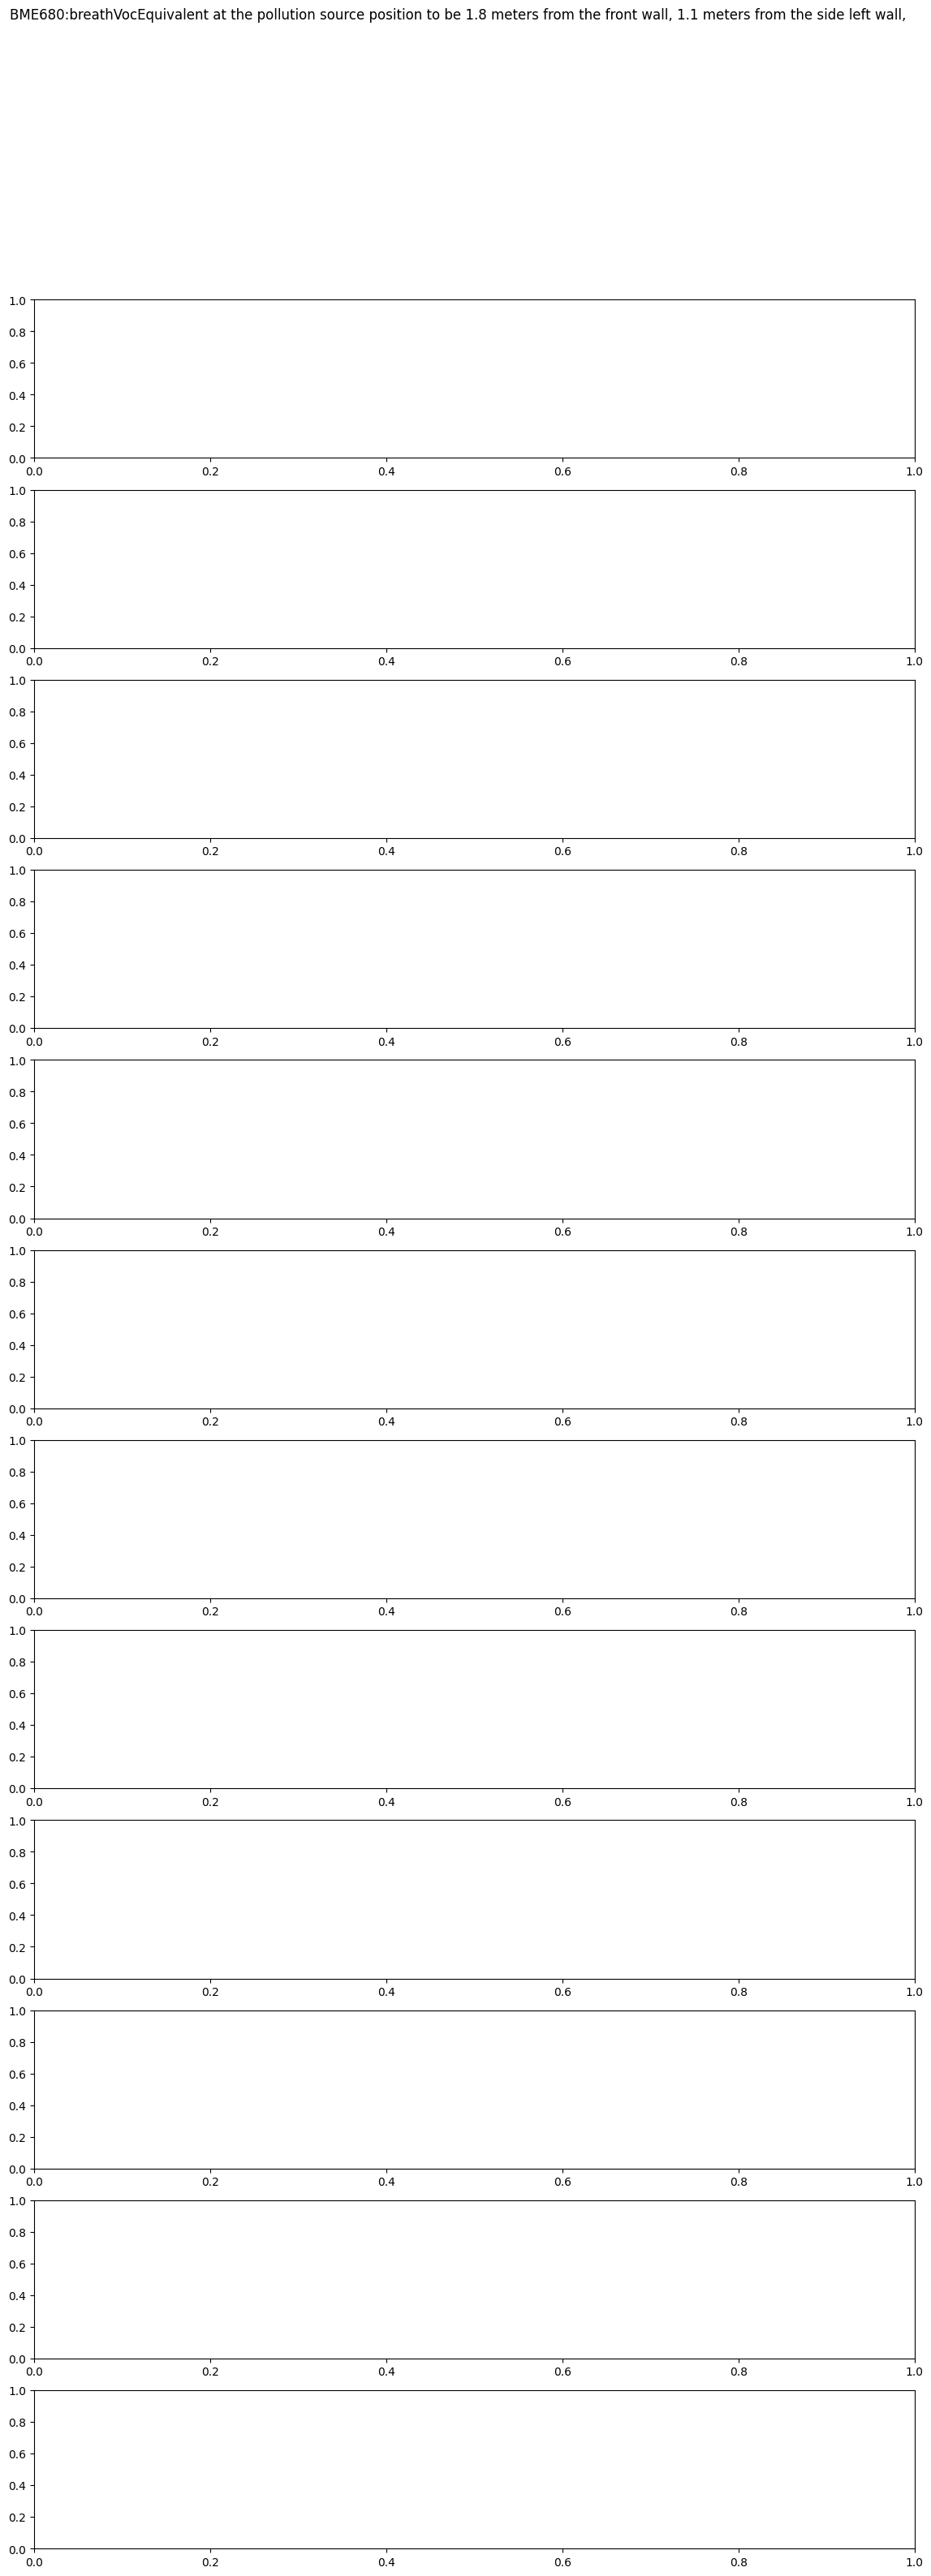

In [150]:
for i in range(0,((df_unique_position_count.shape[0]) - 1)):
        print_time_series_based_of_position(i,df_userInputData_smallScale,df_timeSeriesExperiments,list_of_userInputData_smallScale_based_of_position)

In [ ]:
df_userInputData_smallScale =takeTheUserInputDataFromParticularRoom(df_userInputData,"Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1")
df_userInputData_smallScal